<a href="https://colab.research.google.com/github/tharindu9216/Accident-Severity-Classifier-/blob/Preprocessing/Cascade_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install gdown -q
import gdown

# Download from the shared Google Drive link
file_id = '1qlq6_GgAZRACXnxjuqVoSZJdoZ_WBnrX'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'Road_Accident_Data.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qlq6_GgAZRACXnxjuqVoSZJdoZ_WBnrX
To: /content/Road_Accident_Data.csv
100%|██████████| 69.0M/69.0M [00:01<00:00, 43.9MB/s]


'Road_Accident_Data.csv'

In [4]:
# To Check Data Was Succefully Downloaded.
import pandas as pd

# Load the CSV file
df = pd.read_csv("Road_Accident_Data.csv")

# Display the first 5 rows
print(df.head())


  Accident_Index Accident Date Day_of_Week          Junction_Control  \
0      BS0000001      1/1/2021    Thursday  Give way or uncontrolled   
1      BS0000002      5/1/2021      Monday  Give way or uncontrolled   
2      BS0000003      4/1/2021      Sunday  Give way or uncontrolled   
3      BS0000004      5/1/2021      Monday       Auto traffic signal   
4      BS0000005      6/1/2021     Tuesday       Auto traffic signal   

           Junction_Detail Accident_Severity   Latitude  \
0  T or staggered junction           Serious  51.512273   
1               Crossroads           Serious  51.514399   
2  T or staggered junction            Slight  51.486668   
3  T or staggered junction           Serious  51.507804   
4               Crossroads           Serious  51.482076   

        Light_Conditions Local_Authority_(District) Carriageway_Hazards  ...  \
0               Daylight     Kensington and Chelsea                 NaN  ...   
1               Daylight     Kensington and Chelsea 

In [6]:
# Load & Inspect the Data
import pandas as pd
import numpy as np

df = pd.read_csv('Road_Accident_Data.csv')
print(df.shape)           # (307973, 21)
print(df.dtypes)          # shows column types
print(df.isnull().sum())  # shows missing values per column
print(df['Accident_Severity'].value_counts())  # class distribution

(307973, 21)
Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object
Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail            

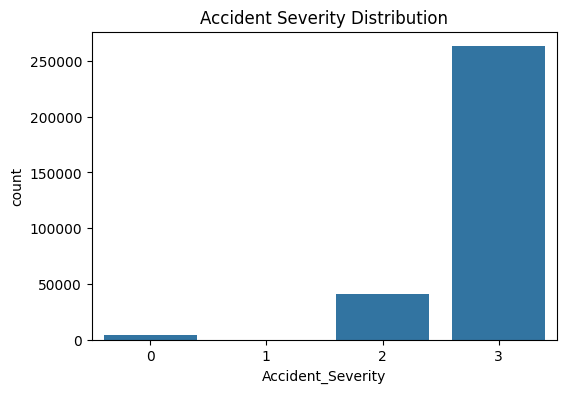

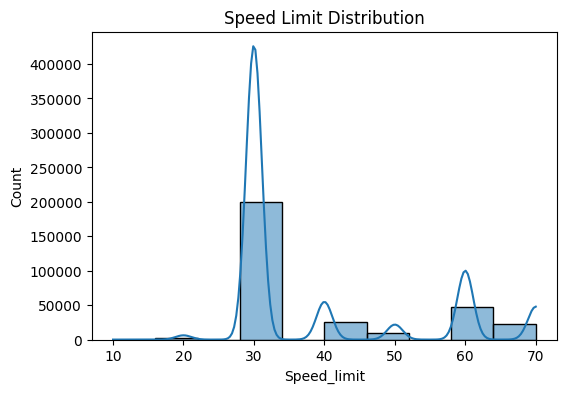

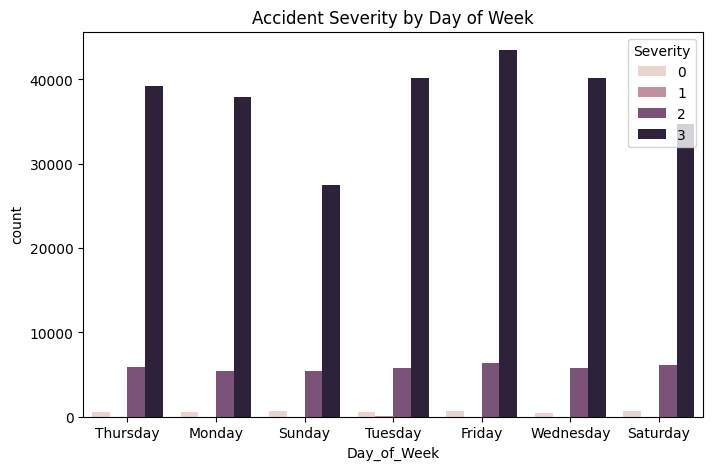

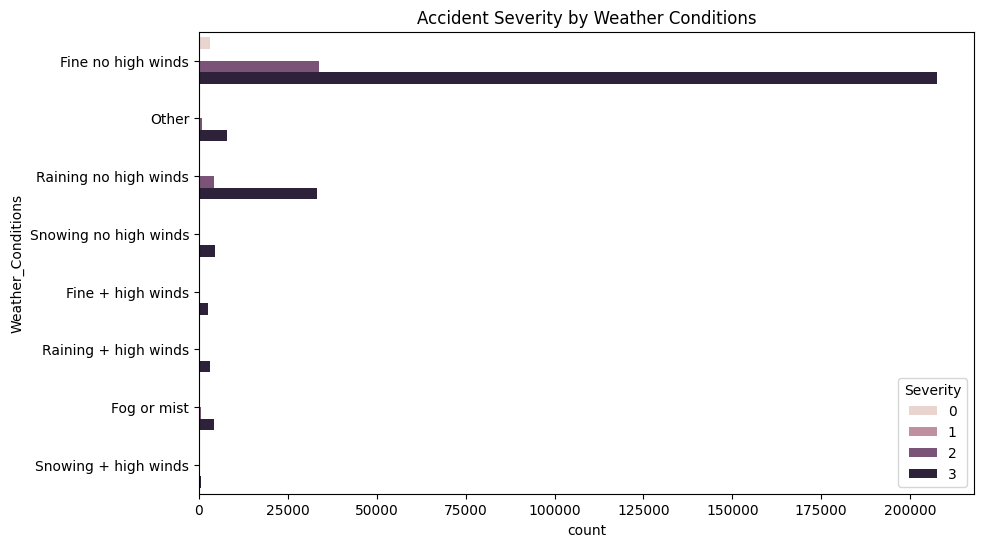

In [21]:
# plots and charts for data-set

import matplotlib.pyplot as plt
import seaborn as sns

# Accident Severity Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()
print()

# Speed Limit Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Speed_limit'], bins=10, kde=True)
plt.title("Speed Limit Distribution")
plt.show()
print()

# Day of Week vs Severity
plt.figure(figsize=(8,5))
sns.countplot(x='Day_of_Week', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Day of Week")
plt.legend(title="Severity")
plt.show()
print()

# Weather Conditions vs Severity
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Weather Conditions")
plt.legend(title="Severity")
plt.show()

In [7]:
# Drop Irrelevant Columns
df = df.drop(columns=['Accident_Index', 'Latitude', 'Longitude',
                       'Local_Authority_(District)', 'Police_Force'])

In [9]:
# Handle Missing Values
from sklearn.impute import SimpleImputer

#Feature Engineering
# Create High_Speed feature: 1 if speed limit >= 60, else 0
df['High_Speed'] = (df['Speed_limit'] >= 60).astype(int)

Classes: ['Fatal' 'Fetal' 'Serious' 'Slight']


In [11]:
# Encode Target Variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Accident_Severity'] = le.fit_transform(df['Accident_Severity'])
# Slight=2, Serious=1, Fatal=0  (alphabetical order)
print('Classes:', le.classes_)

Classes: [0 1 2 3]


In [12]:
# Separate Features (X) and Target (y)
# Define the target column
TARGET = 'Accident_Severity'

# Columns to drop from features
DROP_COLS = ['Accident_Index', 'Accident Date', 'Latitude', 'Longitude',
             'Local_Authority_(District)', 'Police_Force', 'Time']

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET]
print('Feature shape:', X.shape)

Feature shape: (307973, 14)


In [13]:
# Train/Test Split (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # reproducibility seed
    stratify=y           # keep class proportions in both splits
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (246378, 14) | Test: (61595, 14)


In [14]:
# Build Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Pipeline for categorical columns
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Pipeline for numerical columns (tree model version — NO scaling)
num_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# ColumnTransformer applies each pipeline to the right columns
preproc_tree = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe_tree, num_cols)
])

# FIT on training data ONLY — then transform both train and test
preproc_tree.fit(X_train)
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

# Convert sparse matrix to dense for SMOTE compatibility
Xtr_tree_dense = Xtr_tree.toarray() if hasattr(Xtr_tree, 'toarray') else Xtr_tree
Xte_tree_dense = Xte_tree.toarray() if hasattr(Xte_tree, 'toarray') else Xte_tree


In [15]:
# Handle Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Before SMOTE:', Counter(y_train))

sm = SMOTE(random_state=42)
Xtr_res, ytr_res = sm.fit_resample(Xtr_tree_dense, y_train)

print('After SMOTE:', Counter(ytr_res))



Before SMOTE: Counter({3: 210624, 2: 32592, 0: 3123, 1: 39})
After SMOTE: Counter({3: 210624, 0: 210624, 2: 210624, 1: 210624})


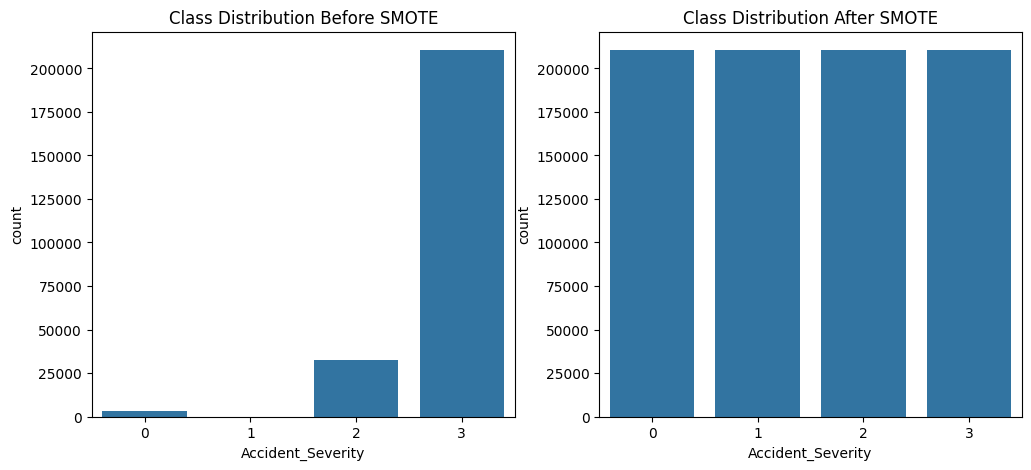

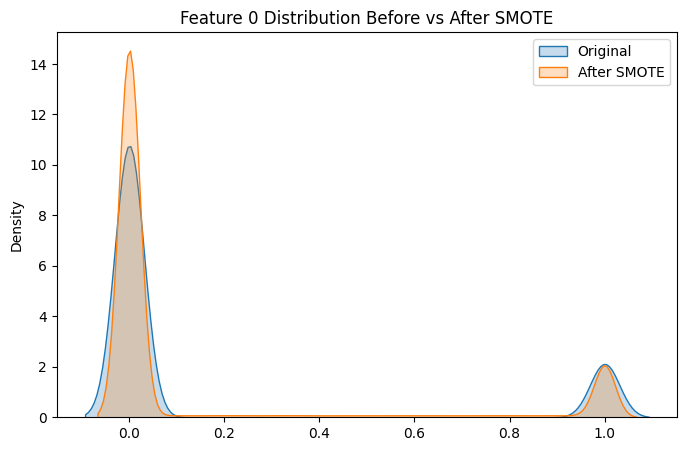

In [22]:
# Plots for handling imbalance before and after.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Class Distribution Before SMOTE")

# After SMOTE
sns.countplot(x=ytr_res, ax=axes[1])
axes[1].set_title("Class Distribution After SMOTE")

plt.show()
print()

# Optional: Compare feature distributions before vs after SMOTE
feature = 0  # pick a feature index (e.g., 0 for first column)
plt.figure(figsize=(8,5))
sns.kdeplot(Xtr_tree_dense[:, feature], label="Original", fill=True)
sns.kdeplot(Xtr_res[:, feature], label="After SMOTE", fill=True)
plt.title(f"Feature {feature} Distribution Before vs After SMOTE")
plt.legend()
plt.show()